Nom Etudiante 1: <font color='green'>Ben Mimoun Sarah</font>
<br>
Nom Etudiante 2: <font color='blue'>Kouidrat Shyrin</font>
<br>
Nom Etudiante 3: <font color='red'>Abunada Dima</font>

# Analyse des données

On vous a attribué un fichiers peaks. Avant d'appliquer les algorithmes de recherche de motif, il convient d'avoir une idée des caractéristiques des séquences qu'il contient. Nous allons faire une courte analyse statistique de ces séquences et visualiser les résultats à l'aide de la bibliothèque `matplotlib`. Voir https://matplotlib.org/stable/ pour la documentation.   

In [1]:
from motifsSearch import readFasta

In [2]:
peaks = readFasta("Sequence_by_Peaks_2.fasta")
print(f'Il y a {len(peaks)} séquences dans le fichier fasta.')

Il y a 109 séquences dans le fichier fasta.


In [3]:
import matplotlib.pyplot as plt

Tracer un histogramme montrant la distribution de la longueur des séquences dans votre fichier peaks. Indiquez aussi la longueur moyenne

In [5]:
?plt.hist 
# pour voir la doc de la fonction hist

Signature:
plt.hist(
    x: 'ArrayLike | Sequence[ArrayLike]',
    bins: 'int | Sequence[float] | str | None' = None,
    *,
    range: 'tuple[float, float] | None' = None,
    density: 'bool' = False,
    weights: 'ArrayLike | None' = None,
    cumulative: 'bool | float' = False,
    bottom: 'ArrayLike | float | None' = None,
    histtype: "Literal['bar', 'barstacked', 'step', 'stepfilled']" = 'bar',
    align: "Literal['left', 'mid', 'right']" = 'mid',
    orientation: "Literal['vertical', 'horizontal']" = 'vertical',
    rwidth: 'float | None' = None,
    log: 'bool' = False,
    color: 'ColorType | Sequence[ColorType] | None' = None,
    label: 'str | Sequence[str] | None' = None,
    stacked: 'bool' = False,
    data=None,
    **kwargs,
) -> 'tuple[np.ndarray | list[np.ndarray], np.ndarray, BarContainer | Polygon | list[BarContainer | Polygon]]'
Docstring:
Compute and plot a histogram.

This method uses `numpy.histogram` to bin the data in *x* and count the
number of values in eac

Longueur moyenne des pics : 268.89 pb


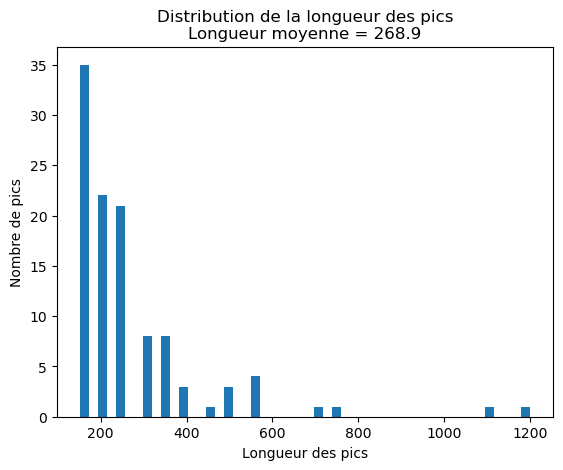

In [7]:
# Distribution de la longueur des pics, et longueur moyenne
    # Calcul des longueurs des séquences
longueurs_peaks = [len(seq) for seq in peaks]
    # Longueur moyenne
longueur_moyenne = sum(longueurs_peaks) / len(longueurs_peaks)

print(f"Longueur moyenne des pics : {longueur_moyenne:.2f} pb")

# Histogramme
plt.hist(longueurs_peaks, bins = 50)
plt.xlabel("Longueur des pics")
plt.ylabel("Nombre de pics")
plt.title(
    "Distribution de la longueur des pics\n"
    f"Longueur moyenne = {longueur_moyenne:.1f}"
)
plt.show()

2. Les brins d'ADN peuvent avoir une fraction de nucléotides `A / T` qui diffère de celle de `G / C`. Écrivez une fonction qui calcule la fraction de `A / T` dans une séquence.

Puis calculez la pour vos séquences peaks et visualisez le résultat avec un histogramme. 


Commentez le résultat: est-il différent de celui attendu pour des séquences aléatoires ? 

La teneur en AT moyenne des pics est de 0.64.


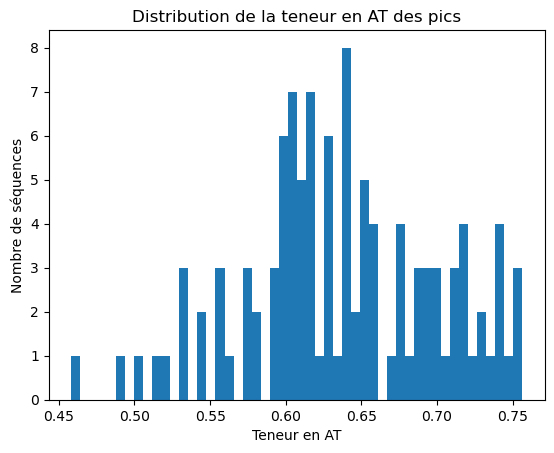

In [16]:
def computeATContent(seq):
    nb_AT = seq.count('a') + seq.count('t')
    return nb_AT / len(seq)
    
AT_content_peaks = [computeATContent(peak) for peak in peaks]
av_AT_content = sum(AT_content_peaks) / len(AT_content_peaks)
print(f'La teneur en AT moyenne des pics est de {av_AT_content:.2f}.')

plt.hist(AT_content_peaks, bins = 50)
plt.xlabel('Teneur en AT')
plt.ylabel('Nombre de séquences')
plt.title('Distribution de la teneur en AT des pics')
plt.show()

    Non il n'est pas différent, on voit ien que plus il y a des séquences plus on se rpproche de 20 pourcent de teneur en AT

**Bonus**: Pour chaque séquence, trouver la longueur du plus long homopolymère (`'AAAA...', 'CCCC...'`, etc...) qu'elle contient. Visualisez vos résultats à l'aide d'un histogramme. Comparez à des séquences aléatoires de nucléotides d'une taille similaire. 
*Indice*: L'expression régulière `r'A+'` matchera tous les homopolymères `'AAA...'`.   

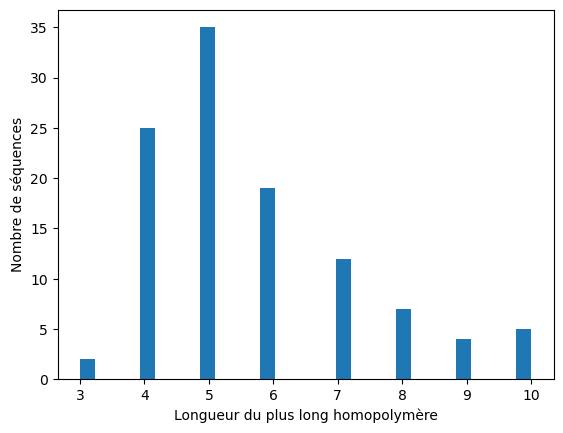

In [22]:
import re

def plusLongHomopolymer(seq):
    max_len = 0
    for base in "atcg" : # pour chaque nucléotides 
        matches = re.findall(base + r'+', seq) # matches : liste de toutes les suites consécutives de la lettre
        # si seq = "AATAAAAT" alors ['AA', 'AAAA']
        if matches : # si on trouve au moins une suite on prend celle sui est la plus grande 
            max_len = max(max_len, max(len(m) for m in matches)) # on garde la plus grande qu'on a trouvé 
    return max_len
    
homopolymer_lengths = [plusLongHomopolymer(seq) for seq in peaks]

plt.hist(homopolymer_lengths, bins = 30)
plt.xlabel('Longueur du plus long homopolymère')
plt.ylabel('Nombre de séquences')
plt.show()

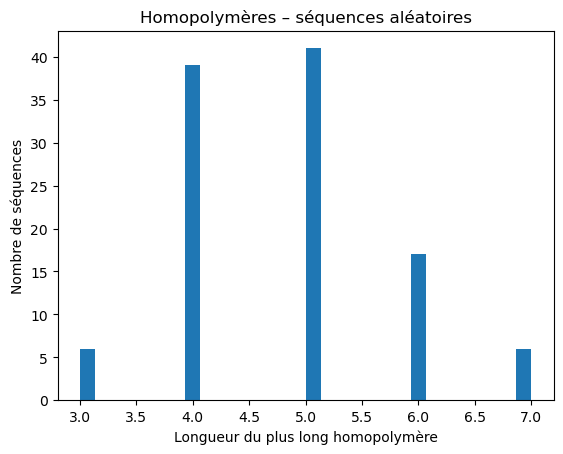

In [26]:
import random

def sequence_aleatoire(length):
    return ''.join(random.choice("atcg") for _ in range(length))
    
random_sequences = [sequence_aleatoire(len(peaks[i])) for i in range (len(peaks))]
homopolymer_lengths = [plusLongHomopolymer(seq) for seq in random_sequences]

plt.hist(homopolymer_lengths, bins = 30)
plt.xlabel('Longueur du plus long homopolymère')
plt.ylabel('Nombre de séquences')
plt.title('Homopolymères – séquences aléatoires')
plt.show()